# Dataset Analysis
This notebook loads the DTI dataset and analyzes the sequence length distribution of proteins and SMILES, as well as basic statistics of DTI pairs.

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Load data
df = pl.read_parquet('datasets/clean.parquet')
print(f'Total number of pairs: {df.height:,}')
print(f'Unique drugs (SMILES): {df["Ligand SMILES"].n_unique():,}')
print(f'Unique proteins: {df["Full_Protein_Sequence"].n_unique():,}')

active_counts = df["is_active"].value_counts()
print(f'\nClass distribution (active/inactive):\n{active_counts}')

Liczba wszystkich par: 451,858
Unikalne leki (SMILES): 236,379
Unikalne białka: 3,580

Rozkład klas (aktywne/nieaktywne):
shape: (2, 2)
┌───────────┬────────┐
│ is_active ┆ count  │
│ ---       ┆ ---    │
│ bool      ┆ u32    │
╞═══════════╪════════╡
│ true      ┆ 216933 │
│ false     ┆ 234925 │
└───────────┴────────┘


In [3]:
# Calculating character lengths (this is an excellent approximation of token count for SMILES and proteins)
df = df.with_columns([
    pl.col("Ligand SMILES").str.len_chars().alias("SMILES_Length"),
    pl.col("Full_Protein_Sequence").str.len_chars().alias("Protein_Length")
])

print("SMILES character length statistics:")
print(df["SMILES_Length"].describe())

print("\nProtein character length statistics:")
print(df["Protein_Length"].describe())

Statystyki długości znakowej SMILES:
shape: (9, 2)
┌────────────┬───────────┐
│ statistic  ┆ value     │
│ ---        ┆ ---       │
│ str        ┆ f64       │
╞════════════╪═══════════╡
│ count      ┆ 451858.0  │
│ null_count ┆ 0.0       │
│ mean       ┆ 61.965381 │
│ std        ┆ 52.515313 │
│ min        ┆ 1.0       │
│ 25%        ┆ 42.0      │
│ 50%        ┆ 53.0      │
│ 75%        ┆ 67.0      │
│ max        ┆ 1609.0    │
└────────────┴───────────┘

Statystyki długości znakowej Białek:
shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 451858.0   │
│ null_count ┆ 0.0        │
│ mean       ┆ 521.84747  │
│ std        ┆ 396.187294 │
│ min        ┆ 7.0        │
│ 25%        ┆ 354.0      │
│ 50%        ┆ 440.0      │
│ 75%        ┆ 548.0      │
│ max        ┆ 7176.0     │
└────────────┴────────────┘


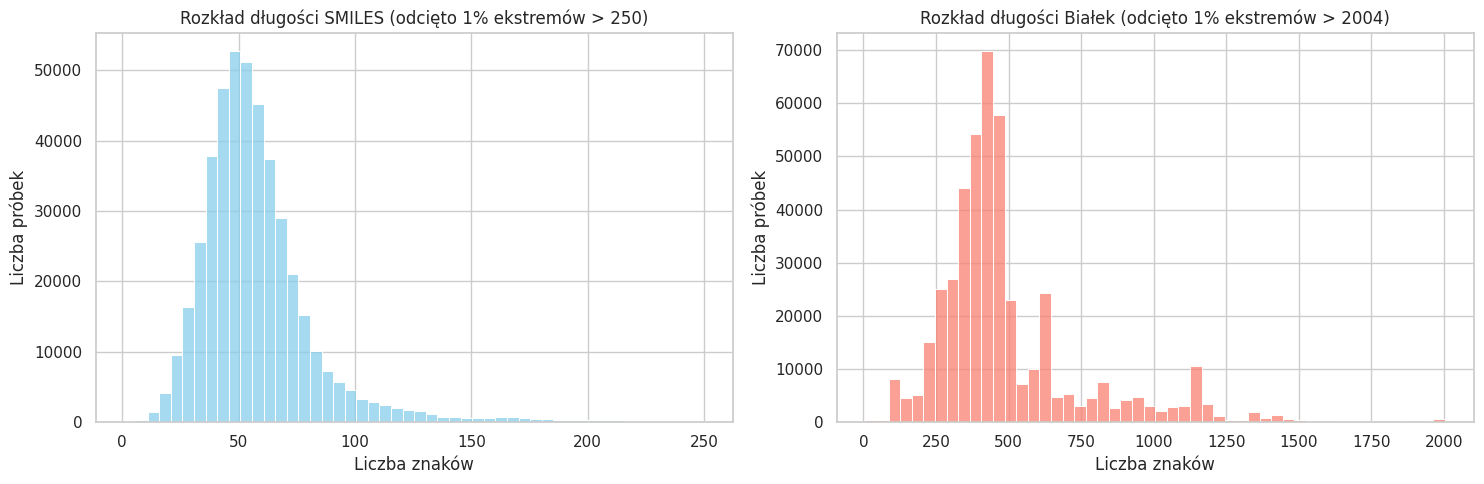

In [4]:
# Distribution plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# We use the 99th percentile to remove extremes for a nicer plot
smiles_p99 = df["SMILES_Length"].quantile(0.99)
protein_p99 = df["Protein_Length"].quantile(0.99)

sns.histplot(df.filter(pl.col("SMILES_Length") <= smiles_p99)["SMILES_Length"].to_numpy(), 
             bins=50, ax=axes[0], color='skyblue')
axes[0].set_title(f'SMILES length distribution (cut off 1% extremes > {int(smiles_p99)})')
axes[0].set_xlabel('Number of characters')
axes[0].set_ylabel('Number of samples')

sns.histplot(df.filter(pl.col("Protein_Length") <= protein_p99)["Protein_Length"].to_numpy(), 
             bins=50, ax=axes[1], color='salmon')
axes[1].set_title(f'Protein length distribution (cut off 1% extremes > {int(protein_p99)})')
axes[1].set_xlabel('Number of characters')
axes[1].set_ylabel('Number of samples')

plt.tight_layout()
plt.show()

### Length Truncation Analysis
In the configuration files we have set `max_length` (e.g. 1024 for ESM2 and 256 for ChemBERT).
Let's see what percentage of our dataset exceeds these values.

In [5]:
max_smiles = 256
max_protein = 1024

smiles_cut = df.filter(pl.col("SMILES_Length") > max_smiles).height / df.height * 100
protein_cut = df.filter(pl.col("Protein_Length") > max_protein).height / df.height * 100

print(f"Percentage of drugs that will be truncated at length {max_smiles}: {smiles_cut:.2f}%")
print(f"Percentage of proteins that will be truncated at length {max_protein}: {protein_cut:.2f}%")

Procent leków, które zostaną obcięte przy długości 256: 0.95%
Procent białek, które zostaną obcięte przy długości 1024: 7.50%


---

## Additional Analysis (Sparsity, Degree Distribution, Class Differences)

### 1. Sparsity of the DTI matrix

Let's check what fraction of all theoretically possible interactions our dataset covers.

In [ ]:
n_samples = df.height
n_drugs = df["Ligand SMILES"].n_unique()
n_targets = df["Full_Protein_Sequence"].n_unique()

total_possible = n_drugs * n_targets
sparsity = (n_samples / total_possible) * 100

print(f"Total possible number of drug-protein combinations: {total_possible:,}")
print(f"Number of pairs in our dataset: {n_samples:,}")
print(f"\nMatrix coverage (Sparsity): {sparsity:.4f}%")
print(f"Our dataset covers only about {sparsity:.3f}% of all possible interactions.")

### 2. Degree Distribution

Shows how well-studied individual proteins are (how many drugs are assigned to them) and how diverse the drugs are (how many proteins their interaction was tested with). We expect a so-called long-tail distribution.

In [ ]:
drugs_per_protein = df.group_by("Full_Protein_Sequence").agg(pl.len().alias("n_drugs"))
proteins_per_drug = df.group_by("Ligand SMILES").agg(pl.len().alias("n_proteins"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Drugs per Protein
axes[0].hist(drugs_per_protein["n_drugs"], bins=50, color="#8b5cf6", log=True)
axes[0].set_title("Protein degree distribution (drugs per protein) - log scale")
axes[0].set_xlabel("Number of assigned drugs")
axes[0].set_ylabel("Number of proteins")

# Proteins per Drug
axes[1].hist(proteins_per_drug["n_proteins"], bins=50, color="#ec4899", log=True)
axes[1].set_title("Drug degree distribution (proteins per drug) - log scale")
axes[1].set_xlabel("Number of assigned proteins")
axes[1].set_ylabel("Number of drugs")

plt.tight_layout()
plt.show()

print("Proteins (How many drugs per protein):")
print(f"  Mean: {drugs_per_protein['n_drugs'].mean():.1f} | Median: {drugs_per_protein['n_drugs'].median()} | Max: {drugs_per_protein['n_drugs'].max():,}")
print("Drugs (How many proteins a drug connects to):")
print(f"  Mean: {proteins_per_drug['n_proteins'].mean():.1f} | Median: {proteins_per_drug['n_proteins'].median()} | Max: {proteins_per_drug['n_proteins'].max():,}")

### 3. Length comparison between classes (Active vs Inactive)

We verify whether the positive and negative classes have a similar length distribution. Differences that are too large could cause the model to learn the heuristic "longer/shorter molecules are a different class" (dataset bias) instead of learning the physics/chemistry of interactions.

In [ ]:
df_len_pd = df.to_pandas()
df_len_pd['Class'] = df_len_pd['is_active'].map({True: 'Active (pKi>=7)', False: 'Inactive (pKi<7)'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# SMILES length by class (we cut off the 99th percentile for chart readability, as in previous ones)
sns.kdeplot(data=df_len_pd[df_len_pd['SMILES_Length'] <= df_len_pd['SMILES_Length'].quantile(0.99)], 
            x="SMILES_Length", hue="Class", fill=True, ax=axes[0], common_norm=False, 
            palette={"Active (pKi>=7)": "#22c55e", "Inactive (pKi<7)": "#ef4444"})
axes[0].set_title("SMILES length distribution by activity class")
axes[0].set_xlabel("Number of characters")

# Protein length by class
sns.kdeplot(data=df_len_pd[df_len_pd['Protein_Length'] <= df_len_pd['Protein_Length'].quantile(0.99)], 
            x="Protein_Length", hue="Class", fill=True, ax=axes[1], common_norm=False, 
            palette={"Active (pKi>=7)": "#22c55e", "Inactive (pKi<7)": "#ef4444"})
axes[1].set_title("Protein sequence length distribution by activity class")
axes[1].set_xlabel("Number of characters")

plt.tight_layout()
plt.show()

---

### 4. pKi Value Distribution

The target variable in its continuous form. The red dashed line marks the activity threshold (pKi = 7.0, i.e. Ki = 100 nM).

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram + KDE
sns.histplot(data=df.to_pandas(), x="pKi", bins=60, kde=True, ax=axes[0], color="#3b82f6")
axes[0].axvline(7.0, color="red", linestyle="--", lw=2, label="Activity threshold (pKi = 7.0)")
axes[0].set_title("pKi Value Distribution")
axes[0].set_xlabel("pKi = -log10(Ki)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Box plot by class
df_pd = df.to_pandas()
df_pd["Class"] = df_pd["is_active"].map({True: "Active", False: "Inactive"})
sns.boxplot(data=df_pd, x="Class", y="pKi", ax=axes[1],
            palette={"Active": "#22c55e", "Inactive": "#ef4444"})
axes[1].axhline(7.0, color="red", linestyle="--", lw=1, alpha=0.5)
axes[1].set_title("pKi Distribution by Class")

plt.tight_layout()
plt.show()

print(f"pKi range: [{df['pKi'].min():.2f}, {df['pKi'].max():.2f}]")
print(f"Mean: {df['pKi'].mean():.3f}  |  Median: {df['pKi'].median():.3f}  |  Std: {df['pKi'].std():.3f}")

---

### 5. Murcko Scaffold Analysis

Since we use **scaffold-based splitting** to divide the data into train/val/test sets, it is important to understand the chemical diversity at the scaffold level. A scaffold is the core ring system of a molecule (Murcko decomposition). If a few scaffolds dominate the dataset, the model might overfit to those particular chemotypes.

In [ ]:
from rdkit import Chem
from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import Counter

def get_scaffold(smiles: str) -> str:
    """Return the generic Murcko scaffold SMILES for a given molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return ""
    try:
        scaffold = MurckoScaffold.MakeScaffoldGeneric(
            MurckoScaffold.GetScaffoldForMol(mol)
        )
        return Chem.MolToSmiles(scaffold)
    except Exception:
        return ""

unique_smiles = df["Ligand SMILES"].unique().to_list()
print(f"Computing scaffolds for {len(unique_smiles):,} unique SMILES ...")
scaffolds = [get_scaffold(s) for s in unique_smiles]

scaffold_counter = Counter(scaffolds)
n_scaffolds = len([s for s in scaffold_counter if s != ""])

print(f"Unique SMILES:    {len(unique_smiles):,}")
print(f"Unique scaffolds: {n_scaffolds:,}")
print(f"Ratio (SMILES / scaffolds): {len(unique_smiles) / n_scaffolds:.1f}x")

In [ ]:
# Top 15 most common scaffolds
top_scaffolds = scaffold_counter.most_common(16)
# skip empty scaffold if present
top_scaffolds = [(s, c) for s, c in top_scaffolds if s != ""][:15]

labels = [s if len(s) < 40 else s[:37] + "..." for s, _ in top_scaffolds]
counts = [c for _, c in top_scaffolds]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(range(len(counts)), counts, color="#6366f1", edgecolor="white")
ax.set_yticks(range(len(counts)))
ax.set_yticklabels(labels, fontsize=9, fontfamily="monospace")
ax.invert_yaxis()
ax.set_xlabel("Number of unique molecules")
ax.set_title("Top 15 Most Common Murcko Scaffolds")
for bar, c in zip(bars, counts):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f"{c:,}", va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of molecules per scaffold (long-tail)
scaffold_sizes = sorted(scaffold_counter.values(), reverse=True)
# remove empty scaffold
scaffold_sizes = [s for s in scaffold_sizes if s > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(scaffold_sizes, bins=50, color="#14b8a6", log=True, edgecolor="white")
axes[0].set_title("Molecules per scaffold (log scale)")
axes[0].set_xlabel("Number of molecules sharing a scaffold")
axes[0].set_ylabel("Number of scaffolds")

# Cumulative coverage
cumsum = np.cumsum(scaffold_sizes) / sum(scaffold_sizes) * 100
axes[1].plot(range(1, len(cumsum)+1), cumsum, color="#f97316", lw=2)
axes[1].set_title("Cumulative molecule coverage by scaffold rank")
axes[1].set_xlabel("Number of scaffolds (ranked by frequency)")
axes[1].set_ylabel("% of all unique molecules covered")
axes[1].axhline(80, color="gray", linestyle="--", lw=1, alpha=0.5, label="80%")
axes[1].axhline(50, color="gray", linestyle=":", lw=1, alpha=0.5, label="50%")
axes[1].legend()

plt.tight_layout()
plt.show()

# How many scaffolds cover 50% and 80% of molecules?
n_50 = np.searchsorted(cumsum, 50) + 1
n_80 = np.searchsorted(cumsum, 80) + 1
print(f"Scaffolds needed to cover 50% of molecules: {n_50:,} (out of {n_scaffolds:,})")
print(f"Scaffolds needed to cover 80% of molecules: {n_80:,} (out of {n_scaffolds:,})")

---

### 6. Amino Acid Composition

Frequency of individual amino acids across all protein sequences. We compare the composition between Active and Inactive classes to check if certain protein types (e.g. cysteine-rich) are overrepresented in one class.

In [ ]:
from collections import Counter as Ctr

STANDARD_AA = list("ACDEFGHIKLMNPQRSTVWY")

def count_aa(sequences: list[str]) -> dict:
    total = Ctr()
    for seq in sequences:
        total.update(seq)
    # Normalize to frequency
    s = sum(total[aa] for aa in STANDARD_AA)
    return {aa: total[aa] / s * 100 for aa in STANDARD_AA}

active_seqs = df.filter(pl.col("is_active"))["Full_Protein_Sequence"].to_list()
inactive_seqs = df.filter(~pl.col("is_active"))["Full_Protein_Sequence"].to_list()

freq_active = count_aa(active_seqs)
freq_inactive = count_aa(inactive_seqs)

x = np.arange(len(STANDARD_AA))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - width/2, [freq_active[aa] for aa in STANDARD_AA], width,
       label="Active", color="#22c55e", alpha=0.8)
ax.bar(x + width/2, [freq_inactive[aa] for aa in STANDARD_AA], width,
       label="Inactive", color="#ef4444", alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(STANDARD_AA, fontsize=12, fontweight="bold")
ax.set_ylabel("Frequency (%)")
ax.set_title("Amino Acid Composition: Active vs Inactive")
ax.legend()
plt.tight_layout()
plt.show()

# Show the biggest differences
diffs = {aa: abs(freq_active[aa] - freq_inactive[aa]) for aa in STANDARD_AA}
sorted_diffs = sorted(diffs.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 amino acids with the largest frequency difference between classes:")
for aa, d in sorted_diffs:
    print(f"  {aa}: Active={freq_active[aa]:.2f}%  Inactive={freq_inactive[aa]:.2f}%  (Δ={d:.2f}pp)")

---

### 7. Duplicate Pair Analysis

We check whether the same (SMILES, protein) pair appears more than once in the dataset. Duplicates could inflate evaluation metrics if the same pair lands in both the training and test sets.

In [ ]:
pair_counts = (
    df
    .group_by(["Ligand SMILES", "Full_Protein_Sequence"])
    .agg(pl.len().alias("n_occurrences"))
)

n_unique_pairs = pair_counts.height
n_duplicated_pairs = pair_counts.filter(pl.col("n_occurrences") > 1).height
n_duplicated_rows = pair_counts.filter(pl.col("n_occurrences") > 1)["n_occurrences"].sum()

print(f"Total rows in dataset:          {df.height:,}")
print(f"Unique (SMILES, protein) pairs:  {n_unique_pairs:,}")
print(f"Pairs appearing more than once:  {n_duplicated_pairs:,}")
if n_duplicated_rows is not None:
    print(f"Total rows from duplicated pairs: {n_duplicated_rows:,}")
    print(f"Duplicate rate: {n_duplicated_pairs / n_unique_pairs * 100:.2f}%")
else:
    print("No duplicates found.")

In [ ]:
if n_duplicated_pairs > 0:
    # Check if duplicated pairs have conflicting labels
    conflicting = (
        df
        .group_by(["Ligand SMILES", "Full_Protein_Sequence"])
        .agg([
            pl.len().alias("n"),
            pl.col("is_active").n_unique().alias("n_labels"),
            pl.col("pKi").mean().alias("mean_pKi"),
            pl.col("pKi").std().alias("std_pKi"),
        ])
        .filter(pl.col("n") > 1)
    )
    n_conflicting = conflicting.filter(pl.col("n_labels") > 1).height
    print(f"Duplicated pairs with CONFLICTING labels (Active in one, Inactive in another): {n_conflicting:,}")
    print(f"Duplicated pairs with CONSISTENT labels: {n_duplicated_pairs - n_conflicting:,}")
    
    if n_conflicting > 0:
        print(f"\nThis means {n_conflicting:,} pairs have measurements on both sides of the pKi=7.0 threshold.")
        print("This is expected — experimental Ki values have inherent measurement noise.")
        print(f"\nSample conflicting pairs:")
        sample = conflicting.filter(pl.col("n_labels") > 1).sort("n", descending=True).head(5)
        print(sample.select(["n", "n_labels", "mean_pKi", "std_pKi"]))
else:
    print("No duplicate pairs found — each (drug, protein) combination is unique.")